In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.CSV")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
!pip install pandas numpy matplotlib seaborn

In [8]:
!pip install pandas numpy matplotlib seaborn

In [10]:
# Initial Data Inspection

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
df.describe()

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Descriptive Statistics:


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


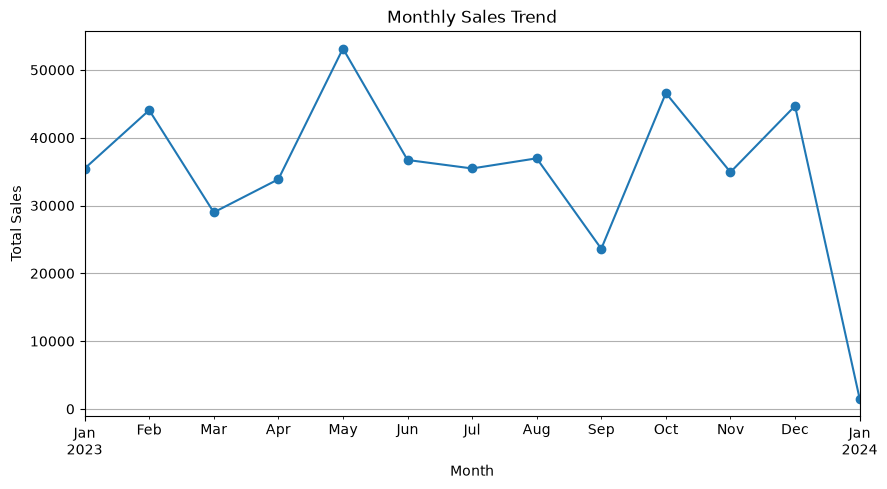

In [11]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Monthly sales
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

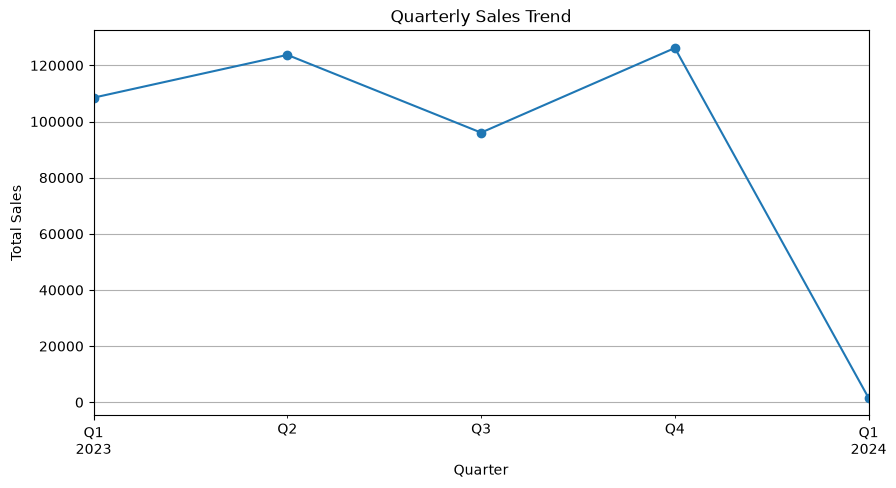

In [12]:
# Quarterly sales
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

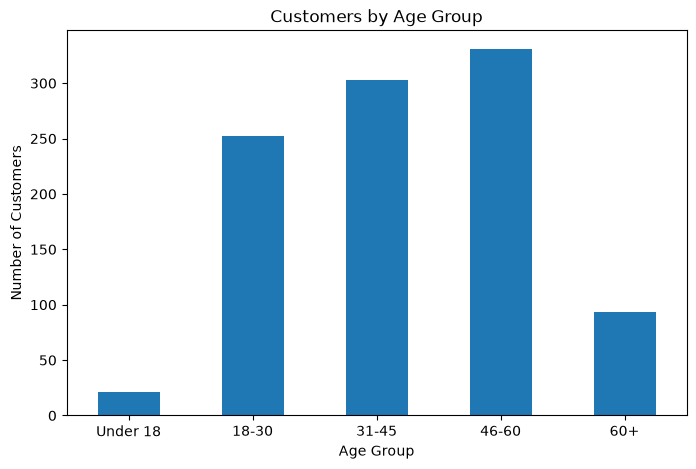

In [13]:
# Create age groups
bins = [0, 18, 30, 45, 60, 100]
labels = ['Under 18', '18-30', '31-45', '46-60', '60+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Count customers by age group
age_group = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(8,5))
age_group.plot(kind='bar')
plt.title('Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

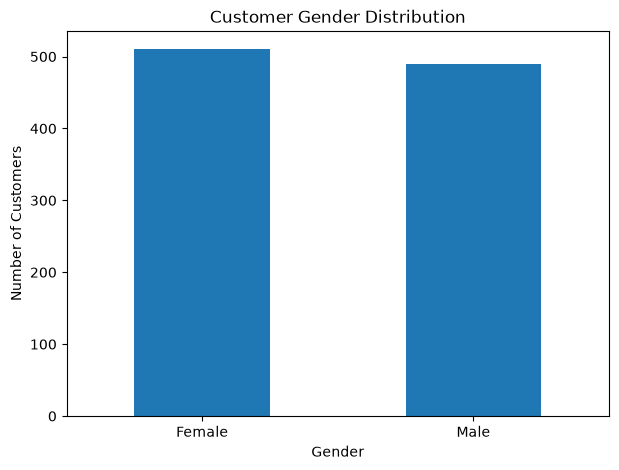

In [14]:
# Gender Analysis

gender_count = df['Gender'].value_counts()

plt.figure(figsize=(7,5))
gender_count.plot(kind='bar')
plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

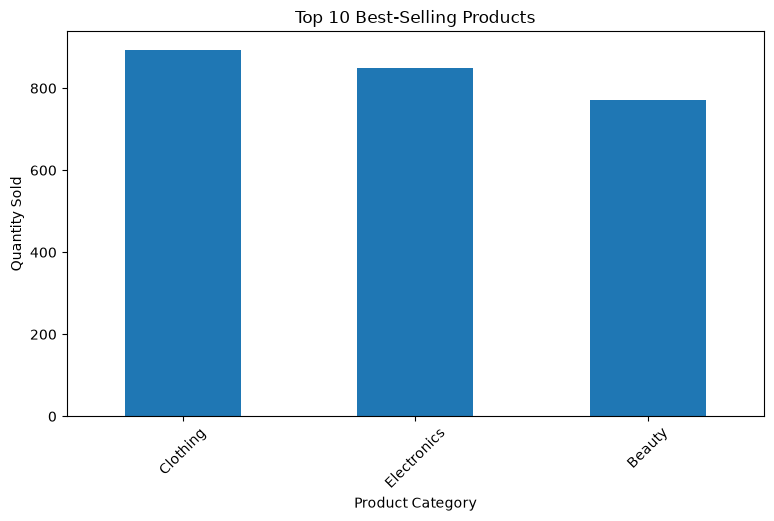

In [15]:
# Top 10 Best-Selling Products

top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
top_products.plot(kind='bar')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

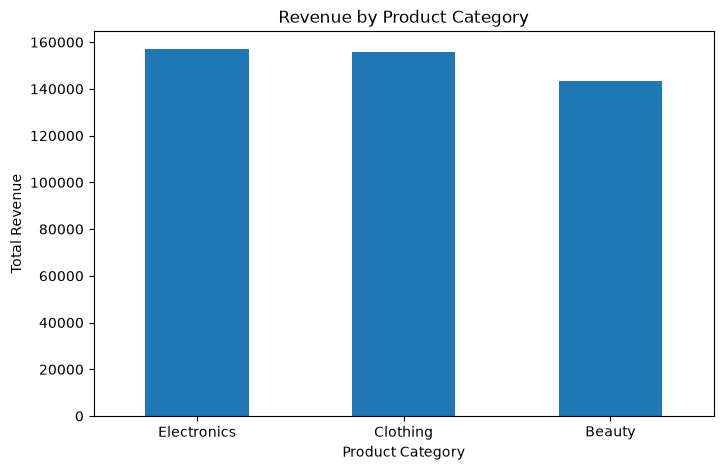

In [16]:
# Revenue by Product Category

category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

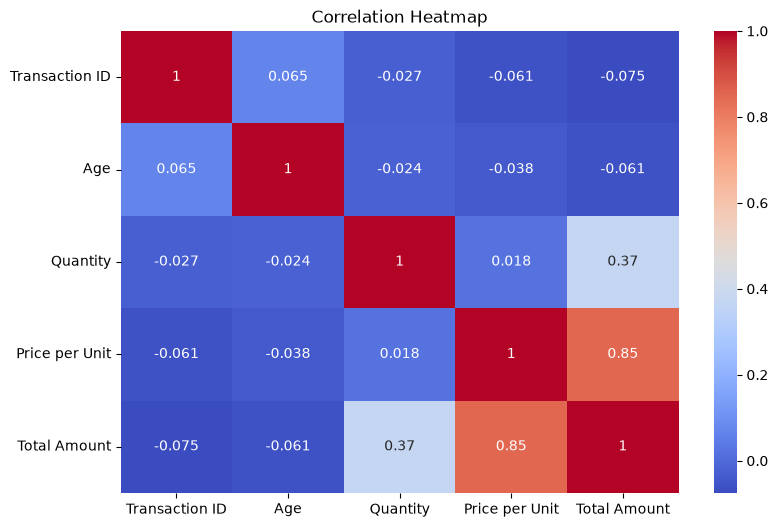

In [17]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

plt.figure(figsize=(9,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

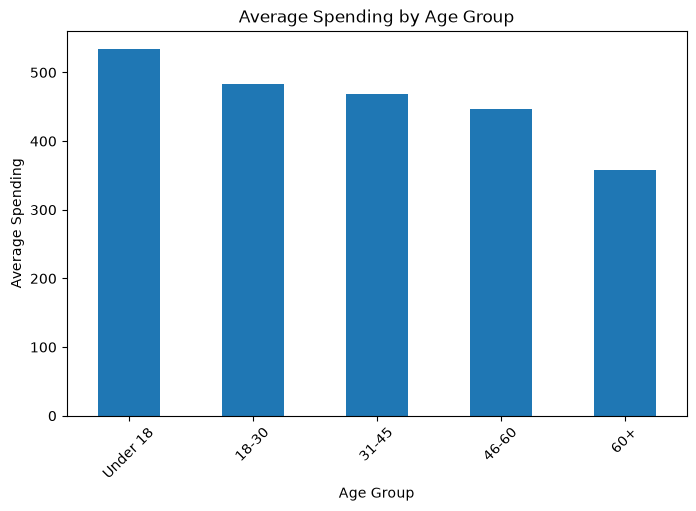

In [18]:
# Additional Visualization - Average Spending by Age Group

age_spending = df.groupby('Age Group')['Total Amount'].mean()

plt.figure(figsize=(8,5))
age_spending.plot(kind='bar')
plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Spending')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Statistical Analysis

numeric_columns = df.select_dtypes(include='number').columns

statistics = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Mode': df[numeric_columns].mode().iloc[0],
    'Standard Deviation': df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Observations

- Monthly sales show variations in revenue across different months.
- Quarterly sales show changes in overall sales performance across quarters.
- The age-group analysis shows the distribution of customers across different age groups.
- Gender analysis shows the number of customers by gender.
- Product category analysis shows which categories contribute more to sales quantity.
- Revenue by category shows differences in revenue generated by each category.
- The correlation heatmap shows relationships between the numerical variables.
- The additional visualization shows differences in average spending across age groups.

## Conclusion

The analysis of the retail sales dataset helped identify sales trends, customer characteristics, product category performance, and relationships between numerical variables.

### Business Recommendations

1. Focus on the product categories that generate higher sales and revenue.
2. Use customer age-group and gender insights to plan targeted marketing campaigns.
3. Monitor monthly and quarterly sales trends to improve inventory and sales planning.